**What factors do affect whether a customer suscribe or not subsribe to a term depoist?**


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

In [ ]:
df1 = pd.read_csv("Bank_1.csv", sep=";")
df2 = pd.read_csv("Bank_2.csv", sep=";")

In [ ]:
df = pd.merge(df1, df2, how="outer")
df.to_csv("Bank_Data.csv", index=False)

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
1,18,student,single,primary,no,608,no,no,cellular,13,nov,210,1,93,1,success,yes
2,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
3,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no
4,18,student,single,secondary,no,156,no,no,cellular,4,nov,298,2,82,4,other,no


In [ ]:
df.shape

(45211, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


**Univariate Numerical Variables**

In [ ]:
def plot_univariate_numeric(
    df,
    col,
    kind="hist",
    bins=30,
    figsize=(6,4),
    title=None,
    color=None
):
    plt.figure(figsize=figsize)

    if kind == "hist":
        sns.histplot(
            df[col].dropna(),
            bins=bins,
            edgecolor="white",
            color=color
        )
        plt.xlabel(col)
        plt.ylabel("Count")

    elif kind == "dot":
        sns.stripplot(
            y=df[col].dropna(),
            jitter=True,
            size=4,
            alpha=0.7,
            color=color
        )
        plt.ylabel(col)

    elif kind == "box":
        sns.boxplot(
            y=df[col].dropna(),
            showfliers=False,
            color=color
        )
        plt.ylabel(col)

    plt.title(title if title else f"{col} Distribution")
    plt.tight_layout()
    plt.show()

    stats = df[col].describe().round(2)
    return stats

**Univariate Categorical Variables**

In [ ]:
def plot_univariate_categorical(
    df,
    col,
    kind="count",
    figsize=(6,4),
    title=None,
    color=None
):
    counts = df[col].value_counts(dropna=False)
    perc   = (counts / counts.sum() * 100).round(2)

    if kind == "count":
        plt.figure(figsize=figsize)
        sns.countplot(
            data=df,
            x=col,
            order=counts.index,
            edgecolor="white",
            color=color
        )
        plt.xticks(rotation=30)
        plt.title(title if title else f"{col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    elif kind == "pie":
        plt.figure(figsize=figsize)

        # if user passes a single color string, repeat it to match len(counts)
        if color is not None:
            if isinstance(color, str):
                pie_colors = [color] * len(counts)
            else:
                # assume user passed a list like ['red','blue',...]
                pie_colors = color
        else:
            pie_colors = None  # matplotlib default

        plt.pie(
            counts.values,
            labels=counts.index.astype(str),
            autopct="%1.1f%%",
            colors=pie_colors
        )
        plt.title(title if title else f"{col} Distribution")
        plt.tight_layout()
        plt.show()

    elif kind == "treemap":
        sorted_counts = counts.sort_values(ascending=True)   # small on top, big bottom
        sorted_perc   = (sorted_counts / sorted_counts.sum() * 100).round(2)

        plt.figure(figsize=figsize)
        plt.barh(
            y=sorted_counts.index.astype(str),
            width=sorted_counts.values,
            edgecolor="white",
            color=color
        )

        # add text label with percent at the end of each bar
        for i, (val, p) in enumerate(zip(sorted_counts.values, sorted_perc)):
            plt.text(
                val,
                i,
                f" {p}%",
                va="center"
            )

        plt.xlabel("Count (size ~ area)")
        plt.ylabel(col)
        plt.title(title if title else f"{col} Distribution (Treemap-style)")
        plt.tight_layout()
        plt.show()

    summary = pd.DataFrame({
        "count": counts,
        "percent": perc
    })

    return summary

In [ ]:
def plot_bivariate_numeric_vs_target(df, num_col, target_col="y",kind="box", figsize=(6,4), title=None):
    plt.figure(figsize=figsize)

    # Palette trick for yes/no aesthetic consistency
    if df[target_col].dtype == "object":
        palette = {"no": "#F94144", "yes": "#277DA1"}
    else:
        palette = None

    if kind == "box":
        sns.boxplot(
            data=df,
            x=target_col,
            y=num_col,
            palette=palette,
            showfliers=False
        )

    elif kind == "barmean":
        means = df.groupby(target_col)[num_col].mean().reset_index()
        sns.barplot(
            data=means,
            x=target_col,
            y=num_col,
            palette=palette,
            edgecolor="white"
        )

    plt.title(title if title else f"{num_col} vs {target_col}")
    plt.xlabel(target_col)
    plt.ylabel(num_col)
    plt.tight_layout()
    plt.show()

    group_means = df.groupby(target_col)[num_col].mean().round(2).to_frame(name=f"avg_{num_col}")
    return group_means

In [ ]:
def plot_bivariate_categorical_vs_target(df, feature_col, target_col="y",kind="bar", order=None,figsize=(6,4), title=None):

    tmp = df.copy()
    # Map yes/no -> 1/0 if needed
    if tmp[target_col].dtype == "object":
        tmp[target_col] = tmp[target_col].map({"yes":1, "no":0})

    rate = tmp.groupby(feature_col)[target_col].mean() * 100

    # apply order if provided (e.g. ['jan','feb',...])
    if order is not None:
        rate = rate.reindex(order)

    # Make dataframe for plotting
    rate_df = rate.reset_index()
    rate_df.columns = [feature_col, "subscription_rate_pct"]

    plt.figure(figsize=figsize)

    if kind == "bar":
        sns.barplot(
            x=feature_col,
            y="subscription_rate_pct",
            data=rate_df,
            order=rate_df[feature_col] if order is None else order,
            edgecolor="white"
        )
        plt.xticks(rotation=30)

    elif kind == "point":
        sns.pointplot(
            x=feature_col,
            y="subscription_rate_pct",
            data=rate_df,
            order=rate_df[feature_col] if order is None else order
        )
        plt.xticks(rotation=30)

    elif kind == "line":
        # good for month trend
        plt.plot(
            rate_df[feature_col],
            rate_df["subscription_rate_pct"],
            marker="o"
        )
        plt.xticks(rotation=30)

    plt.ylabel("Subscription Rate (%)")
    plt.xlabel(feature_col)
    plt.title(title if title else f"{feature_col} vs {target_col}")
    plt.tight_layout()
    plt.show()

    return rate_df.set_index(feature_col).round(2)

In [ ]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']


=== Outcome: Univariate ===


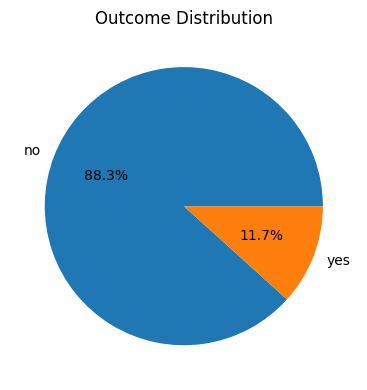

,count,percent
y,,
no,39922,88.3
yes,5289,11.7


In [ ]:
print("=== Outcome: Univariate ===")
outcome_uni_summary = plot_univariate_categorical(
    df,
    col="y",
    kind="pie",
    title="Outcome Distribution"
)
display(outcome_uni_summary)

=== AGE ===


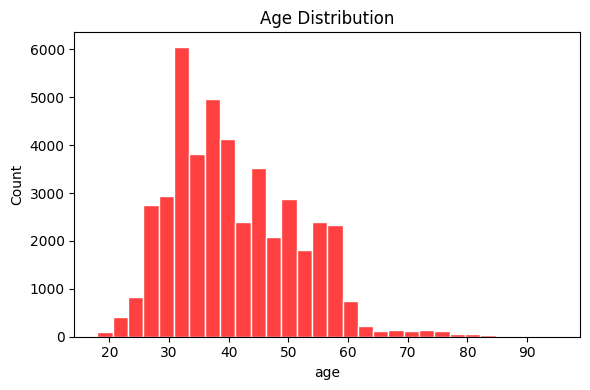

count    45211.00
mean        40.94
std         10.62
min         18.00
25%         33.00
50%         39.00
75%         48.00
max         95.00
Name: age, dtype: float64


In [ ]:
print("=== AGE ===")
age_stats = plot_univariate_numeric(
    df,
    "age",
    kind="hist",
    bins=30,
    figsize=(6,4),
    title="Age Distribution",
    color="red"
)
print(age_stats)

=== Job: Univariate ===


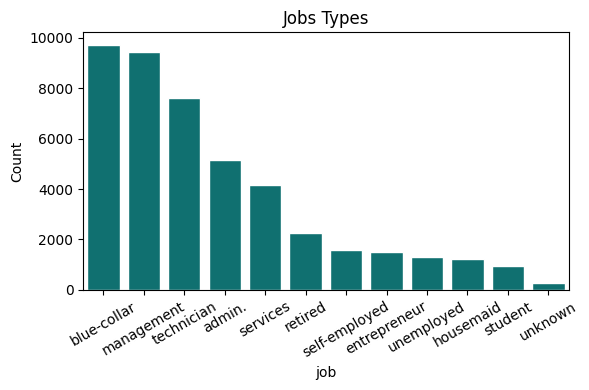

,count,percent
job,,
blue-collar,9732,21.53
management,9458,20.92
technician,7597,16.80
admin.,5171,11.44
services,4154,9.19
retired,2264,5.01
self-employed,1579,3.49
entrepreneur,1487,3.29
unemployed,1303,2.88


In [ ]:
print("=== Job: Univariate ===")
plot_univariate_categorical(
    df,
    "job",
    kind="count",
    title="Jobs Types",
    color="teal"
)

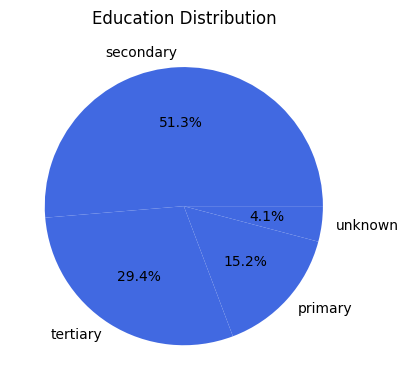

,count,percent
education,,
secondary,23202,51.32
tertiary,13301,29.42
primary,6851,15.15
unknown,1857,4.11


In [ ]:
education_summary = plot_univariate_categorical(
    df,
    col="education",
    kind="pie",
    title="Education Distribution",
    color="royalblue"
)

education_summary

=== MARITAL: Univariate ===


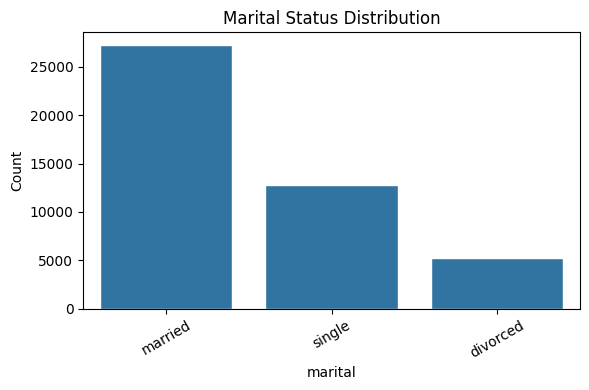

,count,percent
marital,,
married,27214,60.19
single,12790,28.29
divorced,5207,11.52


In [ ]:
print("=== MARITAL: Univariate ===")
marital_uni_summary = plot_univariate_categorical(
    df,
    col="marital",
    kind="count",  # bar countplot
    title="Marital Status Distribution"
)
display(marital_uni_summary)

=== HOUSING: Univariate ===


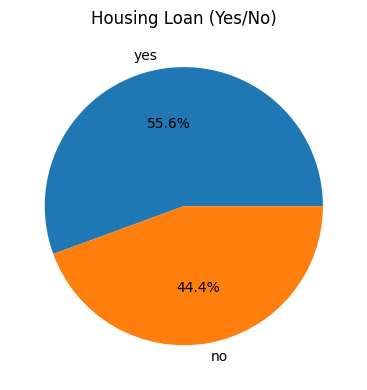

,count,percent
housing,,
yes,25130,55.58
no,20081,44.42


In [ ]:
print("=== HOUSING: Univariate ===")
housing_uni_summary = plot_univariate_categorical(
    df,
    col="housing",
    kind="pie",  # pie chart for this binary variable
    title="Housing Loan (Yes/No)"
)
display(housing_uni_summary)


In [ ]:
scaler = StandardScaler()
df["duration"] = scaler.fit_transform(df[["duration"]])

In [ ]:
scaler = StandardScaler()
df["balance"] = scaler.fit_transform(df[["balance"]])

=== MONTH: bivariate ===


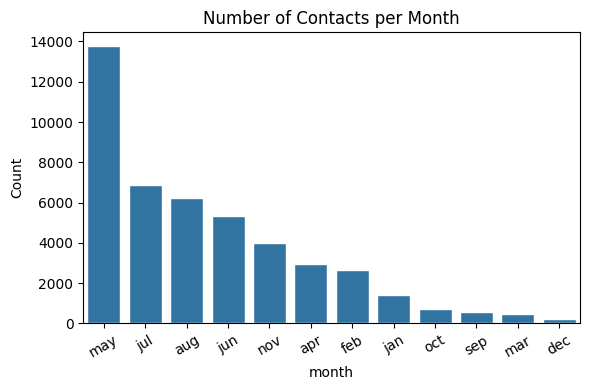

,count,percent
month,,
may,13766,30.45
jul,6895,15.25
aug,6247,13.82
jun,5341,11.81
nov,3970,8.78
apr,2932,6.49
feb,2649,5.86
jan,1403,3.10
oct,738,1.63


In [ ]:
print("=== MONTH: bivariate ===")
month_uni_summary = plot_univariate_categorical(
    df,
    col="month",
    kind="count",  # bar of how many calls each month
    title="Number of Contacts per Month"
)
display(month_uni_summary)

=== AGE: Bivariate vs y ===


/tmp/ipython-input-759600367.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


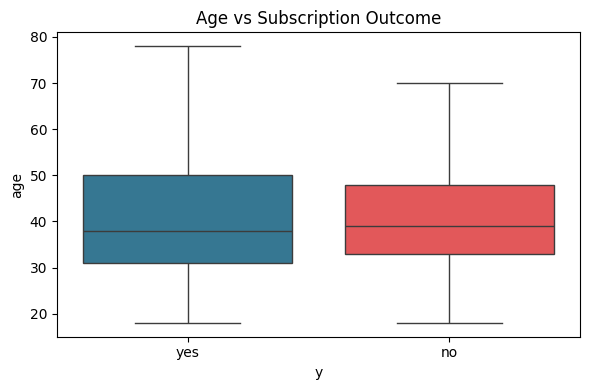

,avg_age
y,
no,40.84
yes,41.67


In [ ]:
print("=== AGE: Bivariate vs y ===")
age_bi_means = plot_bivariate_numeric_vs_target(
    df,
    num_col="age",
    target_col="y",
    kind="box",  # boxplot by yes/no
    title="Age vs Subscription Outcome"
)
display(age_bi_means)

=== DURATION: Bivariate vs y ===


/tmp/ipython-input-759600367.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


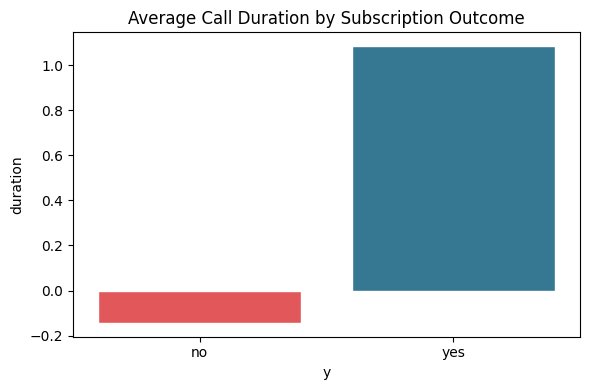

,avg_duration
y,
no,-0.14
yes,1.08


In [ ]:
print("=== DURATION: Bivariate vs y ===")
duration_bi_means = plot_bivariate_numeric_vs_target(
    df,
    num_col="duration",
    target_col="y",
    kind="barmean",  # bar of average duration for yes/no
    title="Average Call Duration by Subscription Outcome"
)
display(duration_bi_means)

=== MARITAL: Bivariate vs y ===


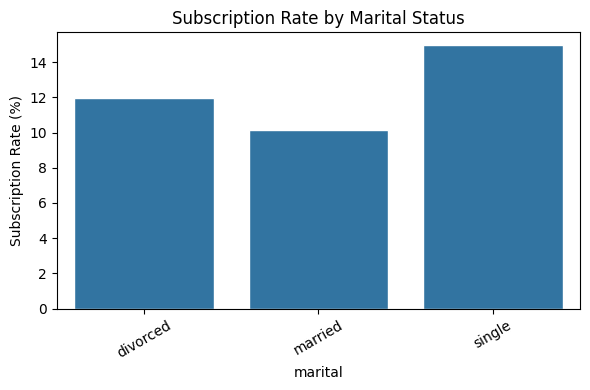

,subscription_rate_pct
marital,
divorced,11.95
married,10.12
single,14.95


In [ ]:
print("=== MARITAL: Bivariate vs y ===")
marital_bi_rates = plot_bivariate_categorical_vs_target(
    df,
    feature_col="marital",
    target_col="y",
    kind="bar",  # bar of subscription rate by marital status
    title="Subscription Rate by Marital Status"
)
display(marital_bi_rates)

=== EDUCATION: Bivariate vs y ===


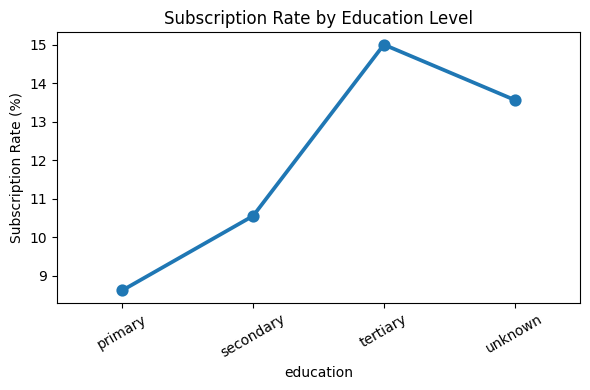

,subscription_rate_pct
education,
primary,8.63
secondary,10.56
tertiary,15.01
unknown,13.57


In [ ]:
print("=== EDUCATION: Bivariate vs y ===")
education_bi_rates = plot_bivariate_categorical_vs_target(
    df,
    feature_col="education",
    target_col="y",
    kind="point",  # pointplot (dot+line), new style
    title="Subscription Rate by Education Level"
)
display(education_bi_rates)

=== HOUSING: Bivariate vs y ===


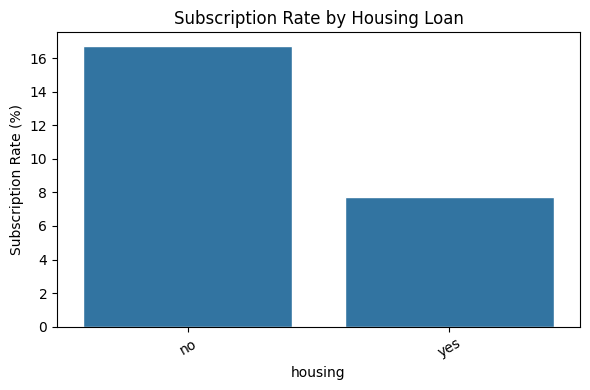

,subscription_rate_pct
housing,
no,16.7
yes,7.7


In [ ]:
print("=== HOUSING: Bivariate vs y ===")
housing_bi_rates = plot_bivariate_categorical_vs_target(
    df,
    feature_col="housing",
    target_col="y",
    kind="bar",  # bar of subscription rate by housing status
    title="Subscription Rate by Housing Loan"
)
display(housing_bi_rates)


=== MONTH: Bivariate vs y ===


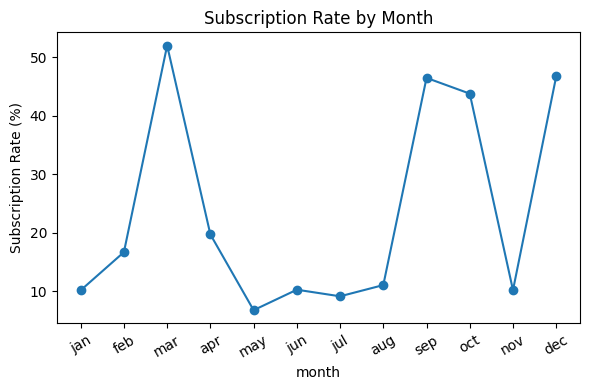

,subscription_rate_pct
month,
jan,10.12
feb,16.65
mar,51.99
apr,19.68
may,6.72
jun,10.22
jul,9.09
aug,11.01
sep,46.46


In [ ]:
print("=== MONTH: Bivariate vs y ===")
month_bi_rates = plot_bivariate_categorical_vs_target(
    df,
    feature_col="month",
    target_col="y",
    kind="line",        # line across months (trend style)
    order=month_order,  # enforce calendar order
    title="Subscription Rate by Month"
)
display(month_bi_rates)

In [ ]:
duration_median = df['duration'].median()
df['call_long'] = (df['duration'] >= duration_median).astype(int)
print("Median call duration:", duration_median)
df.head()

Median call duration: -0.30351651549307


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,call_long
0,18,student,single,primary,no,-0.247730,no,no,cellular,12,aug,0.034315,1,-1,0,unknown,yes,1
1,18,student,single,primary,no,-0.247730,no,no,cellular,13,nov,-0.187023,1,93,1,success,yes,1
2,18,student,single,primary,no,0.191060,no,no,telephone,10,aug,-0.528737,3,-1,0,unknown,no,0
3,18,student,single,secondary,no,-0.445777,no,no,cellular,24,aug,-0.447192,2,-1,0,unknown,no,0
4,18,student,single,secondary,no,-0.396183,no,no,cellular,4,nov,0.154691,2,82,4,other,no,1


In [ ]:
# Binary encoding for yes/no columns inside df_clean
binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-Hot Encoding for the other categorical columns (excluding the binary ones)
categorical_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

bool_cols = df.select_dtypes(include=['bool']).columns

df[bool_cols] = df[bool_cols].astype(int)

print("Dataframe after encoding:")
df.head()

Dataframe after encoding:


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,18,0,-0.247730,0,0,12,0.034315,1,-1,0,...,0,0,0,0,0,0,0,0,0,1
1,18,0,-0.247730,0,0,13,-0.187023,1,93,1,...,0,0,0,0,1,0,0,0,1,0
2,18,0,0.191060,0,0,10,-0.528737,3,-1,0,...,0,0,0,0,0,0,0,0,0,1
3,18,0,-0.445777,0,0,24,-0.447192,2,-1,0,...,0,0,0,0,0,0,0,0,0,1
4,18,0,-0.396183,0,0,4,0.154691,2,82,4,...,0,0,0,0,1,0,0,1,0,0


In [ ]:
# For numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median = df[col].median()
    df[col].fillna(median, inplace=True)



/tmp/ipython-input-4225664541.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median, inplace=True)


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

In [ ]:
X = df.drop(columns=['y'])
y = df['y']


In [ ]:
X.shape

(45211, 43)

In [ ]:
y.shape

(45211,)

In [ ]:
# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**Logistic Regression**

In [ ]:
# Initialize the model with class weighting
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Evaluation
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance:
Accuracy: 0.8390
Precision: 0.4077
Recall: 0.8308
F1 Score: 0.5470
ROC AUC: 0.9092

Confusion Matrix:
[[6708 1277]
 [ 179  879]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7985
           1       0.41      0.83      0.55      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.84      0.72      9043
weighted avg       0.91      0.84      0.86      9043



**Decision Tree Classifier**

In [ ]:
# Initialize the model
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

In [ ]:
# Evaluation
print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Performance:
Accuracy: 0.8737
Precision: 0.4598
Recall: 0.4537
F1 Score: 0.4567
ROC AUC: 0.6915

Confusion Matrix:
[[7421  564]
 [ 578  480]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.45      0.46      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.69      0.69      9043
weighted avg       0.87      0.87      0.87      9043



**Support Vector Machine (SVM)**

In [ ]:
# Create a pipeline: scaling + SVM with probability estimates
svm_model = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight='balanced'))

# Train the model
svm_model.fit(X_train, y_train)

# Predict on test set
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluation
print("Support Vector Machine Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Support Vector Machine Performance:
Accuracy: 0.8531
Precision: 0.4358
Recall: 0.8658
F1 Score: 0.5797
ROC AUC: 0.9233

Confusion Matrix:
[[6799 1186]
 [ 142  916]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7985
           1       0.44      0.87      0.58      1058

    accuracy                           0.85      9043
   macro avg       0.71      0.86      0.75      9043
weighted avg       0.92      0.85      0.87      9043



In [ ]:
def evaluate_model(model, X_test, y_test, model_name="model"):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"=== {model_name} ===")
    print("Accuracy :", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall   :", round(rec, 3))
    print("F1-score :", round(f1, 3))
    print("Confusion Matrix:\n", cm)
    print()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

In [ ]:
depth_values = [2, 3, 4, 5, 6, None]  # None = no limit

tuned_models_results = []
best_model = None
best_f1 = -1

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    result = evaluate_model(
        model,
        X_test,
        y_test,
        model_name=f"DecisionTree (max_depth={d})"
    )

    tuned_models_results.append(result)

    # track best model by F1-score
    if result["f1"] > best_f1:
        best_f1 = result["f1"]
        best_model = model

# 3. show summary table for all tried depths
tuned_models_df = pd.DataFrame(tuned_models_results)
print("Summary of tuned decision trees:")
display(tuned_models_df)

=== DecisionTree (max_depth=2) ===
Accuracy : 0.894
Precision: 0.585
Recall   : 0.329
F1-score : 0.421
Confusion Matrix:
 [[7738  247]
 [ 710  348]]

=== DecisionTree (max_depth=3) ===
Accuracy : 0.9
Precision: 0.648
Recall   : 0.311
F1-score : 0.42
Confusion Matrix:
 [[7806  179]
 [ 729  329]]

=== DecisionTree (max_depth=4) ===
Accuracy : 0.9
Precision: 0.63
Recall   : 0.358
F1-score : 0.457
Confusion Matrix:
 [[7762  223]
 [ 679  379]]

=== DecisionTree (max_depth=5) ===
Accuracy : 0.901
Precision: 0.641
Recall   : 0.352
F1-score : 0.454
Confusion Matrix:
 [[7777  208]
 [ 686  372]]

=== DecisionTree (max_depth=6) ===
Accuracy : 0.9
Precision: 0.629
Recall   : 0.357
F1-score : 0.456
Confusion Matrix:
 [[7762  223]
 [ 680  378]]

=== DecisionTree (max_depth=None) ===
Accuracy : 0.876
Precision: 0.473
Recall   : 0.496
F1-score : 0.485
Confusion Matrix:
 [[7401  584]
 [ 533  525]]

Summary of tuned decision trees:


,model,accuracy,precision,recall,f1
0,DecisionTree (max_depth=2),0.894172,0.584874,0.328922,0.421053
1,DecisionTree (max_depth=3),0.899591,0.647638,0.310964,0.420179
2,DecisionTree (max_depth=4),0.900254,0.629568,0.358223,0.456627
3,DecisionTree (max_depth=5),0.901139,0.641379,0.351607,0.454212
4,DecisionTree (max_depth=6),0.900144,0.628952,0.357278,0.455696
5,DecisionTree (max_depth=None),0.876479,0.473399,0.496219,0.484541


In [ ]:
joblib.dump(best_model, "final_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_features.pkl")

print("Best model saved as final_model.pkl")

Best model saved as final_model.pkl
